In [51]:
import pandas as pd
movies_df = pd.read_csv('/Users/magadi.sudhindra/AIML/ml-latest-small/movies.csv')

In [6]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [52]:
movies_df.shape

(9742, 3)

In [53]:
print(movies_df.iloc[0][0])
print(movies_df.iloc[0][2])



1
Adventure|Animation|Children|Comedy|Fantasy


In [15]:
len(movies_df.index)

9742

In [57]:
movies_df.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [58]:
movies_df['gener_array']=movies_df['genres'].str.split('|')

In [59]:
movies_df.head()

,movieId,title,genres,gener_array
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Comedy,[Comedy]


In [60]:
filter=movies_df.apply(lambda row:'Animation' in row['gener_array'],axis='columns')
filter.head()

0     True
1    False
2    False
3    False
4    False
dtype: bool

In [61]:
adventure_df =movies_df[filter]
adventure_df.head()


,movieId,title,genres,gener_array
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
12,13,Balto (1995),Adventure|Animation|Children,"[Adventure, Animation, Children]"
44,48,Pocahontas (1995),Animation|Children|Drama|Musical|Romance,"[Animation, Children, Drama, Musical, Romance]"
205,239,"Goofy Movie, A (1995)",Animation|Children|Comedy|Romance,"[Animation, Children, Comedy, Romance]"
272,313,"Swan Princess, The (1994)",Animation|Children,"[Animation, Children]"


In [62]:
Dict = {}
for index,row in movies_df.iterrows():
    for genre in row['gener_array']:
        Dict[genre]=Dict.get(genre,0)+1        
print(Dict)

{'Adventure': 1263, 'Animation': 611, 'Children': 664, 'Comedy': 3756, 'Fantasy': 779, 'Romance': 1596, 'Drama': 4361, 'Action': 1828, 'Crime': 1199, 'Thriller': 1894, 'Horror': 978, 'Mystery': 573, 'Sci-Fi': 980, 'War': 382, 'Musical': 334, 'Documentary': 440, 'IMAX': 158, 'Western': 167, 'Film-Noir': 87, '(no genres listed)': 34}


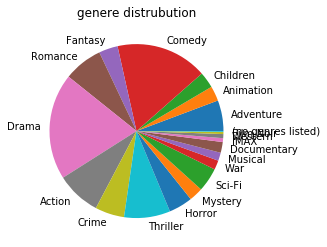

In [41]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.pie(Dict.values(),labels=Dict.keys())
plt.title('genere distrubution')
plt.show()

[]

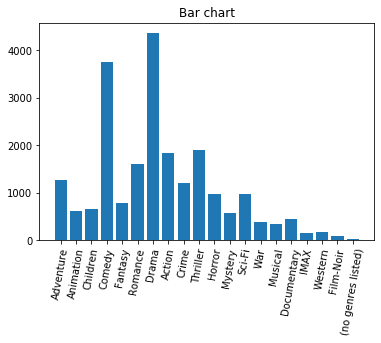

In [43]:
length = list(range(len(Dict)))
plt.xticks(length,Dict.keys(),rotation=80)
plt.bar(length,Dict.values())
plt.title('Bar chart')
plt.plot()

In [64]:
masala_movies_genere = ['Comedy','Romance','Drama']
masala_lambda = lambda x :set(masala_movies_genere).issubset(x['gener_array'])
masala_movies = movies_df[movies_df.apply(masala_lambda ,axis='columns')]
masala_movies

,movieId,title,genres,gener_array
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
10,11,"American President, The (1995)",Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
47,52,Mighty Aphrodite (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
52,58,"Postman, The (Postino, Il) (1994)",Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
83,94,Beautiful Girls (1996),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
...,...,...,...,...
9308,159193,Café Society (2016),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
9310,159415,Swiss Army Man (2016),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
9404,164909,La La Land (2016),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
9628,178615,Front Cover (2016),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"


In [66]:
rating_df = pd.read_csv('/Users/magadi.sudhindra/AIML/ml-latest-small/ratings.csv')

In [67]:
rating_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [68]:
unique_ratings=rating_df['rating'].unique()

In [69]:
unique_ratings.sort()

In [70]:
print(unique_ratings)

[0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


In [73]:
print('No Ratings %d ' % len(rating_df.index))

No Ratings 100836 


In [75]:
print(' No of users %d' % len(rating_df['userId'].unique()))

 No of users 610


In [79]:
import numpy as np
min = np.min(rating_df.rating)
print('min rating given %.lf' %min)

min rating given 0


In [80]:
max = np.max(rating_df.rating)
print('max raring given %.lf' %max)

max raring given 5


In [81]:
median = np.median(rating_df.rating)
print('median rating %.lf' %median)

median rating 4


In [82]:
percentile_25 = np.percentile(rating_df.rating,25)
print('25th percentile %.lf' %percentile_25)

25th percentile 3


In [84]:
percentile_75 = np.percentile(rating_df.rating,75)
print('75th percentile %.lf' % percentile_75)

75th percentile 4


In [86]:
rating_df['rating'].value_counts()


4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: rating, dtype: int64

(array([ 1370.,  2811.,  1791.,  7551.,  5550., 20047., 13136., 26818.,
         8551., 13211.]),
 array([0.5 , 0.95, 1.4 , 1.85, 2.3 , 2.75, 3.2 , 3.65, 4.1 , 4.55, 5.  ]),
 <a list of 10 Patch objects>)

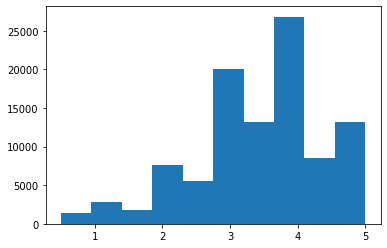

In [87]:
plt.hist(rating_df.rating)


([<matplotlib.axis.XTick at 0x11c0ae450>,
 <a list of 11 Text xticklabel objects>)

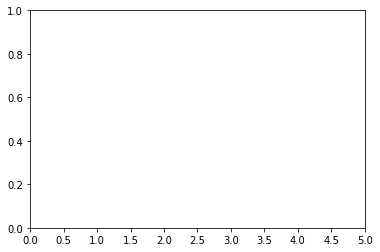

In [88]:
plt.xticks([0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0])

Text(0.5, 0, 'rating')

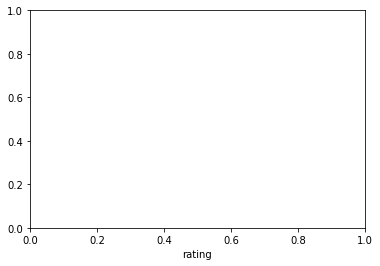

In [89]:
plt.xlabel('rating')

Text(0, 0.5, '# of movies')

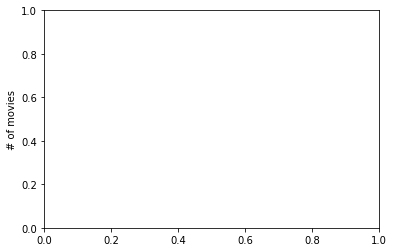

In [91]:
plt.ylabel('# of movies')

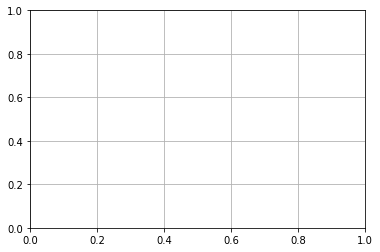

In [92]:
plt.grid()
plt.show()

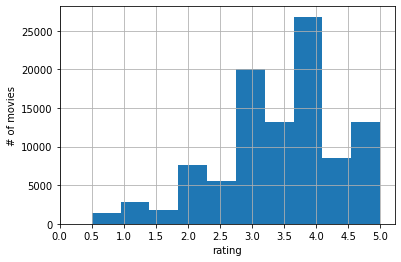

In [93]:
plt.hist(rating_df.rating)
plt.xticks([0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0])
plt.xlabel('rating')
plt.ylabel('# of movies')
plt.grid()
plt.show()

In [97]:
ratings_view= rating_df[['movieId','rating']]
ratings_view.groupby(['movieId'],as_index=False).mean().sort_values(by='rating',ascending=False).head(10)

,movieId,rating
7638,88448,5.0
8089,100556,5.0
9065,143031,5.0
9076,143511,5.0
9078,143559,5.0
4245,6201,5.0
8136,102217,5.0
8130,102084,5.0
4240,6192,5.0
9104,145994,5.0


In [100]:
merged_df= pd.merge(rating_df,movies_df,on='movieId')
merged_df.head()

,userId,movieId,rating,timestamp,title,genres,gener_array
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,5,1,4.0,847434962,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
2,7,1,4.5,1106635946,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
3,15,1,2.5,1510577970,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
4,17,1,4.5,1305696483,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"


In [101]:
ratings_view= merged_df[['movieId','rating','title']]
ratings_view.groupby(['movieId','title'],as_index=False).mean().sort_values(by='rating',ascending=False).head(10)

,movieId,title,rating
7638,88448,Paper Birds (Pájaros de papel) (2010),5.0
8089,100556,"Act of Killing, The (2012)",5.0
9065,143031,Jump In! (2007),5.0
9076,143511,Human (2015),5.0
9078,143559,L.A. Slasher (2015),5.0
4245,6201,Lady Jane (1986),5.0
8136,102217,Bill Hicks: Revelations (1993),5.0
8130,102084,Justice League: Doom (2012),5.0
4240,6192,Open Hearts (Elsker dig for evigt) (2002),5.0
9104,145994,Formula of Love (1984),5.0


In [106]:
len(merged_df[merged_df['movieId']==88448].index)

1